# Notebook that goes through the IC outputs

<img src="img/prodflow_nexus_TWF.png" alt="TWF" width="500"/>
<img src="img/prodflow_TWF_pmaps.png" alt="PMAPS" width="410"/>



<img src="img/prodflow_data_v2.0.png" alt="prodflow" width="910"/>


In [119]:
import ast

import numpy as np 

import tables as tb
import pandas as pd 

import matplotlib.pyplot as plt

from invisible_cities.core.system_of_units import *
from invisible_cities.database             import load_db as db

In [208]:
event = 10

base_path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/208Tl/prod/PORT_1a/prod/{city}/{city}_1_208Tl.h5'

## [DETSIM](https://pr18-sw-docs.readthedocs.io/en/latest/detsim.html)

Detector simulation. Takes the true hits from MC fast simulation and returns True Waveforms.

In [209]:
detfile = base_path.format(city = 'detsim')

with tb.open_file(detfile, 'r') as h5in:
    print(h5in)

/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/208Tl/prod/PORT_1a/prod/detsim/detsim_1_208Tl.h5 (File) ''
Last modif.: '2025-01-29T20:54:00+00:00'
Object Tree: 
/ (RootGroup) ''
/pmtrd (EArray(107, 60, 60000)shuffle, zlib(4)) ''
/sipmrd (EArray(107, 3584, 1500)shuffle, zlib(4)) ''
/Filters (Group) ''
/Filters/active_hits (Table(107,)shuffle, zlib(4)) 'Event has passed filter flag'
/Filters/dark_events (Table(107,)shuffle, zlib(4)) 'Event has passed filter flag'
/Filters/signal (Table(107,)shuffle, zlib(4)) 'Event has passed filter flag'
/MC (Group) ''
/MC/configuration (Table(31,)shuffle, zlib(4)) ''
/MC/event_mapping (Table(107,)shuffle, zlib(4)) ''
/MC/hits (Table(80506,)shuffle, zlib(4)) ''
/MC/particles (Table(9876,)shuffle, zlib(4)) ''
/MC/sns_positions (Table(0,)shuffle, zlib(4)) ''
/MC/sns_response (Table(0,)shuffle, zlib(4)) ''
/Run (Group) ''
/Run/eventMap (Table(107,)shuffle, zlib(4)) 'event & nexus evt for each index'
/Run/events (Table(107,)shuffle, zl

File contains:
* **MC info**: copied from the MC file
* **Run Info***: event mapping and timestamp info
* **Filters**: tables with information of which events passed certain filters 
* **Config**: configuration info
* **pmtrd & sipmrd**: True Waveforms for PMTs and SiPMs, with shape $(N_{event}, N_{sensor}, N_{timeslice})$

In [210]:
detconf = pd.read_hdf(detfile, 'config/detsim')
detconf

,variable,value
0,files_in,['/mnt/lustre/scratch/nlsas//home/usc/ie/mpm/N...
1,file_out,/mnt/lustre/scratch/nlsas//home/usc/ie/mpm/NEX...
2,compression,ZLIB4
3,run_number,0
4,detector_db,next100
5,print_mod,10000
6,event_range,"(None,)"
7,s1_lighttable,$LUSTRE/NEXT100/LightTables/NEXT100_S1_LT.h5
8,s2_lighttable,$LUSTRE/NEXT100/LightTables/NEXT100_S2_LT.h5
9,sipm_psf,$LUSTRE/NEXT100/LightTables/NEXT100_PSF.h5


The detsim configuration mainly has:
* **physics params**: contain information of the values used to simulate the different physical processes of the detector --> scintillation energy for Xe $w_s$, ionization energy for Xe $w_i$, fano factor and conde policarpo factor (from https://arxiv.org/pdf/1105.2954), drift velocities & diffusion parameters (from Magboltz simulations, knowing the P and the E field), EL gain (from https://doi.org/10.1016/j.physletb.2010.01.013), and lifetime (from estimations...)
* **buffer params**: contains information about the WF shape we want to define (from real specifications, like the measuring time of each sensor to create the slices)

We can plot the WF using the information from **pmtrd** and **sipmrd**, and we can scale the X axis (time) using the buffer information

In [212]:
buffer_params = ast.literal_eval(detconf.iloc[11].value)
pmt_width  = buffer_params['pmt_width']
sipm_width = buffer_params['sipm_width']

In [213]:
with tb.open_file(detfile, 'r') as h5in:
    pmtrd = h5in.root.pmtrd[:]
    sipmrd = h5in.root.sipmrd[:]

We can select one event and sum for all the sensors to obtain the summed waveform:

In [214]:
pmt_counts = pmtrd[event].sum(axis = 0)
sipm_counts = sipmrd[event].sum(axis = 0)

Also, we can create the time axis creating a array from 0 to $N_{timeslice}$ and multiplying by the width of the time slice:

In [215]:
pmt_times = np.arange(0, pmtrd.shape[-1], 1) * pmt_width
sipm_times = np.arange(0, sipmrd.shape[-1], 1) * sipm_width

Text(0, 0.5, 'Amplitude (pes)')

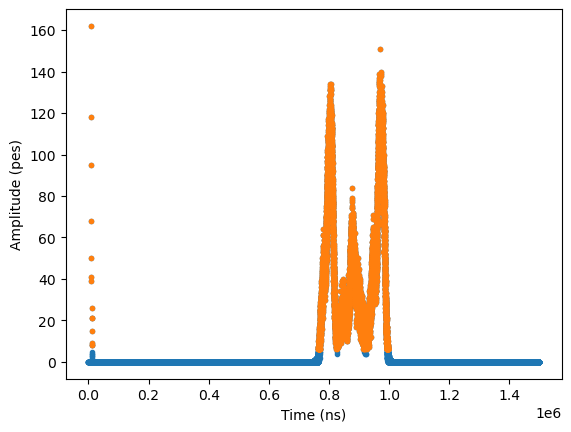

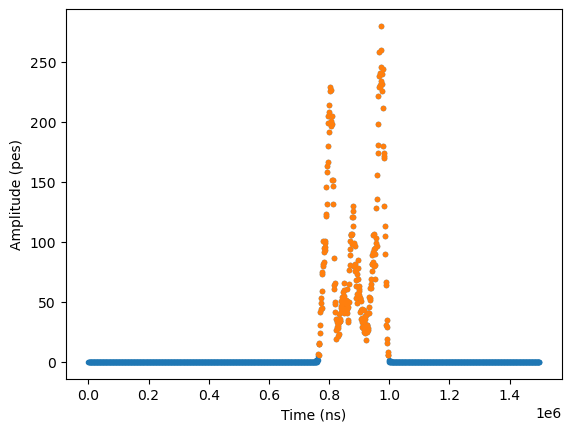

In [216]:
plt.figure(1)
mask_pmt = pmt_counts > 5
plt.plot(pmt_times, pmt_counts, '.')
plt.plot(pmt_times[mask_pmt], pmt_counts[mask_pmt], '.')
plt.xlabel(r'Time (ns)')
plt.ylabel('Amplitude (pes)')
# plt.xlim((9 * mus, 11 * mus))

plt.figure(2)
mask_sipm = sipm_counts > 5
plt.plot(sipm_times, sipm_counts, '.')
plt.plot(sipm_times[mask_sipm], sipm_counts[mask_sipm], '.')
plt.xlabel(r'Time (ns)')
plt.ylabel('Amplitude (pes)')
# plt.xlim((11 * mus, 1500 * mus))

# [HYPATHIA](https://next-exp-sw.readthedocs.io/en/latest/hypathia.html#)

Takes the True Waveforms and searchs for the S1 and S2 signals. For the Fast Simulation it is fair easy because we have defined in detsim where the S1 is (using the `pre_trigger` value in the config). Then based on some initial estimation of each signal, the city extracts the information

In [217]:
hypfile = base_path.format(city = 'hypathia')

with tb.open_file(hypfile, 'r') as h5in:
    print(h5in)

/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/208Tl/prod/PORT_1a/prod/hypathia/hypathia_1_208Tl.h5 (File) ''
Last modif.: '2025-01-29T20:55:49+00:00'
Object Tree: 
/ (RootGroup) ''
/Filters (Group) ''
/Filters/empty_pmap (Table(107,)shuffle, zlib(4)) 'Event has passed filter flag'
/Filters/s12_indices (Table(107,)shuffle, zlib(4)) 'Event has passed filter flag'
/MC (Group) ''
/MC/configuration (Table(31,)shuffle, zlib(4)) ''
/MC/event_mapping (Table(107,)shuffle, zlib(4)) ''
/MC/hits (Table(80506,)shuffle, zlib(4)) ''
/MC/particles (Table(9876,)shuffle, zlib(4)) ''
/MC/sns_positions (Table(0,)shuffle, zlib(4)) ''
/MC/sns_response (Table(0,)shuffle, zlib(4)) ''
/PMAPS (Group) ''
/PMAPS/S1 (Table(2598,)shuffle, zlib(4)) 'S1 Table'
/PMAPS/S1Pmt (Table(155880,)shuffle, zlib(4)) 'S1Pmt Table'
/PMAPS/S2 (Table(19998,)shuffle, zlib(4)) 'S2 Table'
/PMAPS/S2Pmt (Table(1199880,)shuffle, zlib(4)) 'S2Pmt Table'
/PMAPS/S2Si (Table(10816306,)shuffle, zlib(4)) 'S2Si Table'
/Run

File contains:
* **MC info**: copied from the MC file
* **Run Info***: event mapping and timestamp info
* **Filters**: tables with information of which events passed certain filters 
* **Config**: configuration info
* **PMAPS**: Peak Maps with the S1 and S2 information for each found peak (given that more than one peak can be found; not for fast sim probably, but for real data), both per sensor and already summed.

In [218]:
# S1 and S2 summed signals for the peaks
s1 = pd.read_hdf(hypfile, 'PMAPS/S1')
s2 = pd.read_hdf(hypfile, 'PMAPS/S2')

# S1 and S2 signals for the peaks and for each sensor
s1_pmt = pd.read_hdf(hypfile, 'PMAPS/S1Pmt')
s2_pmt = pd.read_hdf(hypfile, 'PMAPS/S2Pmt')
s2_sipm = pd.read_hdf(hypfile, 'PMAPS/S2Si')

In [219]:
# Selection of an event for the time summed S1 and S2
s1_peak = s1[s1.event == event]
s2_peak = s2[s2.event == event]

# Selection of an event for the S1 and S2 and summing all the time slices response
s1_pmt_peak = s1_pmt[s1_pmt.event == event].groupby('npmt').sum().reset_index()[['npmt', 'ene']]
s2_pmt_peak = s2_pmt[s2_pmt.event == event].groupby('npmt').sum().reset_index()[['npmt', 'ene']]
s2_sipm_peak = s2_sipm[s2_sipm.event == event].groupby('nsipm').sum().reset_index()[['nsipm', 'ene']]


We can check the output or each summed peak with respect to the time:

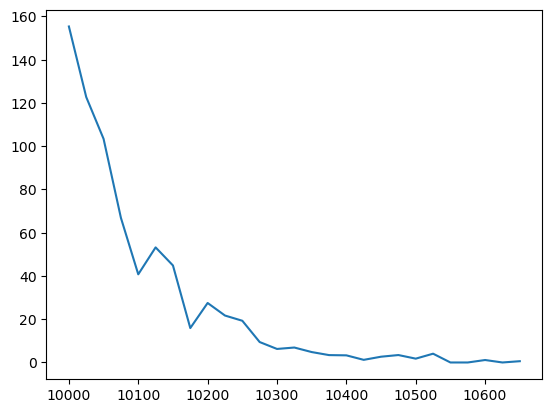

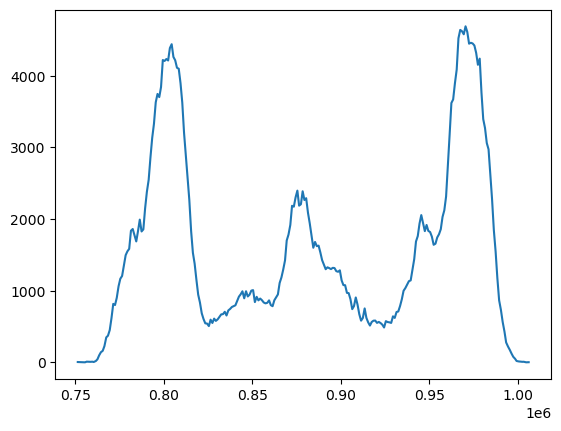

In [220]:
plt.figure(1)
plt.plot(s1_peak.time, s1_peak.ene)
plt.figure(2)
plt.plot(s2_peak.time, s2_peak.ene)

And now for an event where we have summed all the time response for each sensor, we add the sensors position to check visually the collection for each sensor and for each S1 and S2

In [221]:
datapmt  = db.DataPMT ('next100', 0)
datasipm = db.DataSiPM('next100', 0)

In [222]:
s1_pmt_peak  = s1_pmt_peak.merge (datapmt .reset_index().rename(columns = {'index':'npmt'}) [['npmt',  'X', 'Y']], on = 'npmt',  how = 'outer').fillna(0)
s2_pmt_peak  = s2_pmt_peak.merge (datapmt .reset_index().rename(columns = {'index':'npmt'}) [['npmt',  'X', 'Y']], on = 'npmt',  how = 'outer').fillna(0)
s2_sipm_peak = s2_sipm_peak.merge(datasipm.reset_index().rename(columns = {'index':'nsipm'})[['nsipm', 'X', 'Y']], on = 'nsipm', how = 'outer').fillna(0)

Text(0, 0.5, 'Y (mm)')

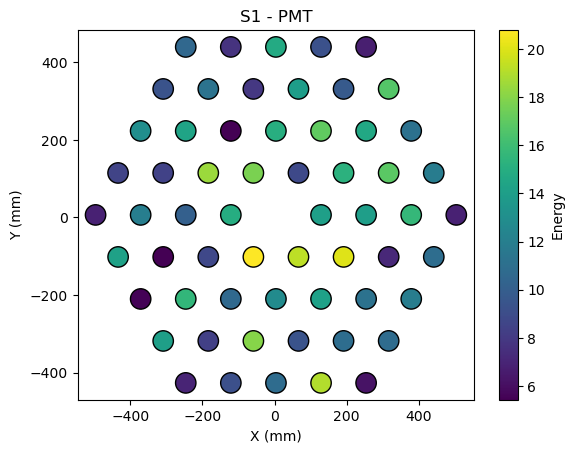

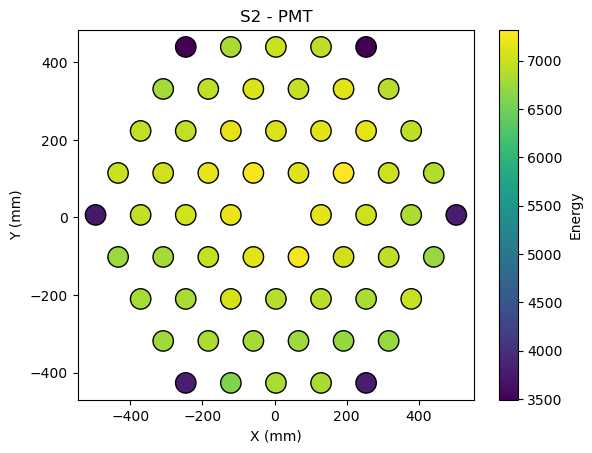

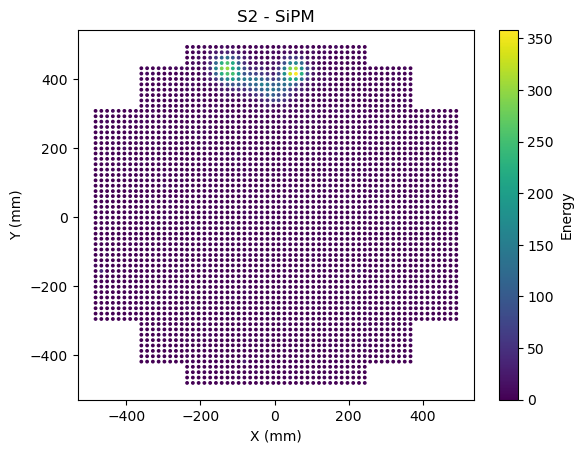

In [223]:
# Convert 76 mm diameter to cm and then to points
diameter_cm = 7.6  # 76mm = 7.6cm
diameter_points = diameter_cm * 28.35  # Convert cm to points

plt.figure(1)
plt.scatter(s1_pmt_peak['X'], s1_pmt_peak['Y'], c=s1_pmt_peak['ene'], cmap='viridis', edgecolors='k', s = diameter_points)
plt.colorbar(label='Energy')
plt.title('S1 - PMT')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')

plt.figure(2)
plt.scatter(s2_pmt_peak['X'], s2_pmt_peak['Y'], c=s2_pmt_peak['ene'], cmap='viridis', edgecolors='k', s = diameter_points)
plt.colorbar(label='Energy')
plt.title('S2 - PMT')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')

plt.figure(3)
plt.scatter(s2_sipm_peak['X'], s2_sipm_peak['Y'], c=s2_sipm_peak['ene'], cmap='viridis', s = 3)
plt.colorbar(label='Energy')
plt.title('S2 - SiPM')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')

# [SOPHRONIA](https://next-exp-sw.readthedocs.io/en/latest/sophronia.html)



Takes the S1 and S2 signal and makes a 3D reconstruction of the track (using time difference of S1 and S2 for Z, and the S2 SiPM response for X and Y).